# Battery SOH Estimation — GRU Training Pipeline (v2)

**Fixes over v1:**
- Scaler fitted on train only; test uses `transform()` only (no data leakage)
- Datasets built per-cell before concatenation (no cross-cell window contamination)
- SOH-normalized target (`capacity / initial_capacity`) for cell-agnostic generalisation
- Validation loop with early stopping and LR scheduler
- Full metric suite: MSE, RMSE, MAE, MAPE
- Robust `.mat` key extraction from filename


In [6]:
!pip cache purge
!conda clean --all -y

Files removed: 4157 (1435.5 MB)
Directories removed: 28
Will remove 660 (1.58 GB) tarball(s).
Will remove 1 index cache(s).
Will remove 36 (87.6 MB) package(s).
Will remove 56127 tempfile(s).
There are no logfile(s) to remove.


In [1]:
import os
import copy
import scipy.io
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

## 1. Feature Extraction
Voltage-windowed trapezoidal integration (4.0 V → 3.2 V) plus thermal / time features.
Returns raw capacity **and** SOH normalised to the cell's own first-cycle capacity.


In [ ]:
def extract_nasa_features(mat_file_path: str) -> pd.DataFrame:
    """
    Parse a NASA battery .mat file and return a DataFrame of per-cycle features.

    FIX (v1 bug): key derived from filename — avoids fragile dict-ordering hack.
    """
    mat = scipy.io.loadmat(mat_file_path)
    filename = os.path.splitext(os.path.basename(mat_file_path))[0]  # e.g. 'B0005'
    cycles = mat[filename][0, 0]['cycle'][0]

    cycle_data = []
    initial_capacity = None

    for c in cycles:
        if c['type'][0] != 'discharge':
            continue

        data = c['data'][0, 0]
        true_capacity = float(data['Capacity'][0, 0])

        # Anchor SOH to the very first discharge capacity of this cell
        if initial_capacity is None:
            initial_capacity = true_capacity

        v_array    = data['Voltage_measured'][0]
        i_array    = data['Current_measured'][0]
        t_array    = data['Time'][0]
        temp_array = data['Temperature_measured'][0]

        # --- Voltage-windowed trapezoidal integration (4.0 V -> 3.2 V) ---
        mask = (v_array <= 4.0) & (v_array >= 3.2)
        cutoff_idx = np.where(mask)[0]

        if len(cutoff_idx) > 1:
            i_trunc = np.abs(i_array[cutoff_idx])
            t_trunc = t_array[cutoff_idx]
            dt      = np.diff(t_trunc)
            avg_i   = (i_trunc[:-1] + i_trunc[1:]) / 2.0
            voltage_window_cap = np.sum(avg_i * dt) / 3600.0  # seconds -> Ah
        else:
            voltage_window_cap = 0.0

        # SOH: normalised to first-cycle capacity - cell-agnostic target
        soh = true_capacity / initial_capacity

        cycle_data.append({
            'window_capacity_ah': voltage_window_cap,
            'initial_temp'      : float(temp_array[0]),
            'max_temp'          : float(np.max(temp_array)),
            'duration'          : float(t_array[-1] - t_array[0]),
            'target_capacity'   : true_capacity,
            'soh'               : soh,
            'initial_capacity'  : initial_capacity,
        })

    return pd.DataFrame(cycle_data)


## 2. Dataset & DataLoader
**FIX (v1 bug):** `scaler` is now an optional parameter.
- Train dataset: `scaler=None` -> `fit_transform` (sets statistics)
- Val / test datasets: pass the *train* scaler -> `transform` only (no leakage)


In [3]:
class BatterySequenceDataset(Dataset):
    """
    Sliding-window sequence dataset for GRU training.

    Parameters
    ----------
    df         : DataFrame from extract_nasa_features()
    lookback   : sequence length (default 5)
    scaler     : fitted StandardScaler from train set, or None to fit a new one
    target_col : column to predict ('soh' for normalised, 'target_capacity' for raw Ah)
    """
    FEATURE_COLS = ['window_capacity_ah', 'initial_temp', 'max_temp', 'duration']

    def __init__(self, df: pd.DataFrame, lookback: int = 5,
                 scaler=None, target_col: str = 'soh'):
        features = df[self.FEATURE_COLS].values
        targets  = df[target_col].values

        # FIX: only fit on train data; test/val reuse the train scaler
        if scaler is None:
            self.scaler = StandardScaler()
            scaled = self.scaler.fit_transform(features)
        else:
            self.scaler = scaler
            scaled = self.scaler.transform(features)

        X, y = [], []
        for i in range(len(scaled) - lookback):
            X.append(scaled[i : i + lookback])
            y.append(targets[i + lookback])

        self.X = torch.tensor(np.array(X), dtype=torch.float32)
        self.y = torch.tensor(np.array(y), dtype=torch.float32).unsqueeze(-1)

    def __len__(self):               return len(self.X)
    def __getitem__(self, idx):      return self.X[idx], self.y[idx]


## 3. GRU Model
Slightly deeper than v1 (2 layers, wider hidden dim, optional dropout) to better capture long-range degradation trends.


In [4]:
class BatterySohGRU(nn.Module):
    """
    GRU-based SOH estimator.

    Parameters
    ----------
    input_dim  : number of input features (4)
    hidden_dim : GRU hidden size
    num_layers : stacked GRU layers
    dropout    : dropout probability between GRU layers (ignored when num_layers=1)
    """
    def __init__(self, input_dim: int, hidden_dim: int,
                 num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_dim, hidden_dim, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.gru(x)          # [B, seq_len, hidden_dim]
        last   = out[:, -1, :]        # last time-step hidden state
        return self.fc(last)           # [B, 1]


## 4. Load & Inspect Data


In [5]:
df_b0005 = extract_nasa_features('Data/B0005.mat')
df_b0006 = extract_nasa_features('Data/B0006.mat')
df_b0007 = extract_nasa_features('Data/B0007.mat')

for name, df in [('B0005', df_b0005), ('B0006', df_b0006), ('B0007', df_b0007)]:
    print(f"{name} | cycles: {len(df):3d} | "
          f"initial cap: {df['initial_capacity'].iloc[0]:.4f} Ah | "
          f"final SOH: {df['soh'].iloc[-1]:.4f}")


B0005 | cycles: 168 | initial cap: 1.8565 Ah | final SOH: 0.7138
B0006 | cycles: 168 | initial cap: 2.0353 Ah | final SOH: 0.5825
B0007 | cycles: 168 | initial cap: 1.8911 Ah | final SOH: 0.7575


## 5. Build Datasets

**FIX (v1 bug - cross-cell window contamination):**
Previously both cells were concatenated into one DataFrame *before* windowing,
so lookback windows straddled the B0005/B0006 boundary.
Now each cell gets its own dataset first; tensors are concatenated after windowing.

**FIX (v1 bug - data leakage):**
Scaler is fitted on `ds_b0005` only. B0006 and B0007 reuse that scaler via `transform`.


In [12]:
LOOKBACK   = 10
BATCH_SIZE = 16

# Fit scaler on B0005, reuse for all others
ds_b0005 = BatterySequenceDataset(df_b0005, lookback=LOOKBACK)
train_scaler = ds_b0005.scaler

ds_b0006 = BatterySequenceDataset(df_b0006, lookback=LOOKBACK, scaler=train_scaler)
ds_b0007 = BatterySequenceDataset(df_b0007, lookback=LOOKBACK, scaler=train_scaler)

# Combine B0005 + B0006 for training - no cross-cell boundary contamination
train_dataset = ConcatDataset([ds_b0005, ds_b0006])
test_dataset  = ds_b0007

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Train samples : {len(train_dataset)}")
print(f"Test  samples : {len(test_dataset)}")
print(f"Input shape   : {ds_b0005.X.shape}  (samples, lookback, features)")


Train samples : 316
Test  samples : 158
Input shape   : torch.Size([158, 10, 4])  (samples, lookback, features)


## 6. Initialise Model, Loss & Optimizer


In [13]:
model     = BatterySohGRU(input_dim=4, hidden_dim=32, num_layers=2, dropout=0.2)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# Halve LR if val loss stalls for 10 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)

n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal trainable parameters: {n_params}")


BatterySohGRU(
  (gru): GRU(4, 32, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

Total trainable parameters: 10017


## 7. Training Loop with Early Stopping

Validation is run against B0007 each epoch to drive early stopping and the LR scheduler.
Best model weights are checkpointed and restored after training.

> **Note:** In a fuller setup, use a fourth held-out cell (e.g. B0018) for validation
> so B0007 remains a truly unseen test set.


In [14]:
EPOCHS   = 150
PATIENCE = 20

best_val_loss = float('inf')
patience_ctr  = 0
best_weights  = None
train_losses, val_losses = [], []

val_X = test_dataset.X
val_y = test_dataset.y

for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(batch_X), batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_train = epoch_loss / len(train_loader)
    train_losses.append(avg_train)

    # --- Validation ---
    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(val_X), val_y).item()
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    # Checkpoint best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights  = copy.deepcopy(model.state_dict())
        patience_ctr  = 0
    else:
        patience_ctr += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train MSE: {avg_train:.5f} | "
              f"Val MSE: {val_loss:.5f} | "
              f"Patience: {patience_ctr}/{PATIENCE}")

    if patience_ctr >= PATIENCE:
        print(f"\n>> Early stopping triggered at epoch {epoch + 1}")
        break

# Restore best checkpoint
model.load_state_dict(best_weights)
print(f"\nBest validation MSE: {best_val_loss:.6f}")


Epoch  10/150 | Train MSE: 0.00277 | Val MSE: 0.00289 | Patience: 0/20
Epoch  20/150 | Train MSE: 0.00137 | Val MSE: 0.00166 | Patience: 4/20
Epoch  30/150 | Train MSE: 0.00119 | Val MSE: 0.00367 | Patience: 14/20

>> Early stopping triggered at epoch 36

Best validation MSE: 0.000532


## 8. Evaluation - Full Metric Suite
MSE, RMSE, and MAE are in SOH units [0-1]; multiply by 100 for percentage points.


In [15]:
model.eval()
with torch.no_grad():
    preds_soh = model(test_dataset.X).numpy().flatten()
    true_soh  = test_dataset.y.numpy().flatten()

mse  = mean_squared_error(true_soh, preds_soh)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(true_soh, preds_soh)
mape = float(np.mean(np.abs((true_soh - preds_soh) / true_soh)) * 100)

print("=" * 50)
print("  Evaluation Results - Battery B0007 (unseen)")
print("=" * 50)
print(f"  MSE  (SOH^2)  : {mse:.6f}")
print(f"  RMSE (SOH)    : {rmse:.4f}   ({rmse * 100:.2f} pp)")
print(f"  MAE  (SOH)    : {mae:.4f}   ({mae  * 100:.2f} pp)")
print(f"  MAPE          : {mape:.2f}%")
print("=" * 50)


  Evaluation Results - Battery B0007 (unseen)
  MSE  (SOH^2)  : 0.000532
  RMSE (SOH)    : 0.0231   (2.31 pp)
  MAE  (SOH)    : 0.0209   (2.09 pp)
  MAPE          : 2.41%


## 9. Visualisation


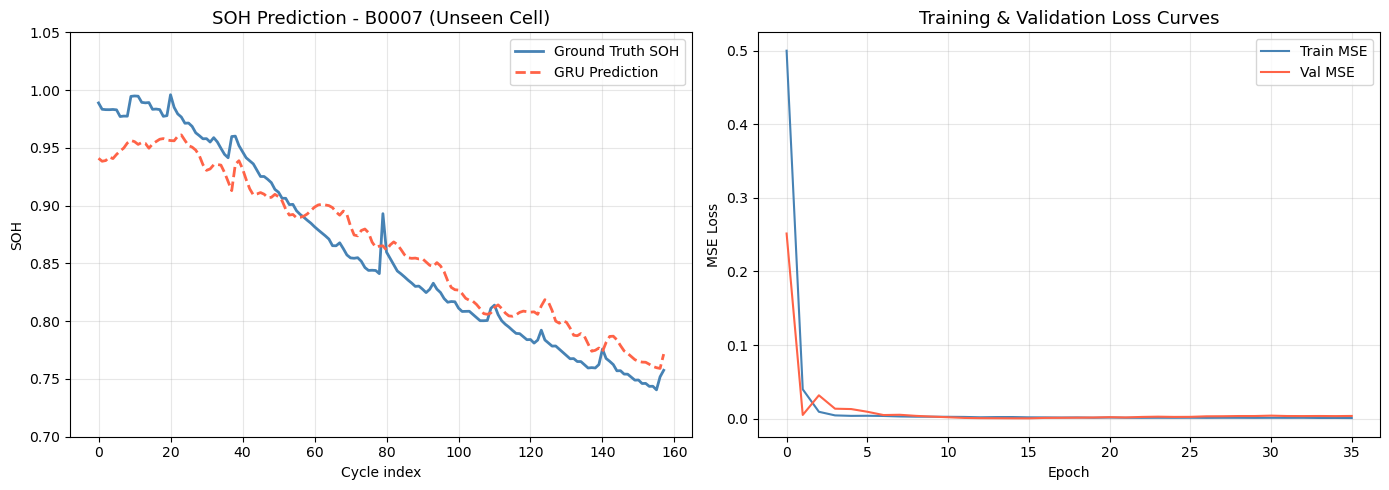

Figure saved to training_results_v2.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Prediction vs Ground Truth ---
axes[0].plot(true_soh,  label='Ground Truth SOH', linewidth=2, color='steelblue')
axes[0].plot(preds_soh, label='GRU Prediction',   linewidth=2, color='tomato', linestyle='--')
axes[0].set_title('SOH Prediction - B0007 (Unseen Cell)', fontsize=13)
axes[0].set_xlabel('Cycle index')
axes[0].set_ylabel('SOH')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.7, 1.05])

# --- Right: Training curves ---
axes[1].plot(train_losses, label='Train MSE', color='steelblue')
axes[1].plot(val_losses,   label='Val MSE',   color='tomato')
axes[1].set_title('Training & Validation Loss Curves', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_results_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to training_results_v2.png')
